<link rel="stylesheet" href="../../styles.css">
<div class="note">
<h1>Gradient descent</h1>
<p>The way deep learning models learn at a high level follows these steps:
<ul>
<li>Guess the solution</li>
<li>Compute the error (mistake)</li>
<li>Learn from the mistake and modify parameters</li>
</ul>
</p>
<p>We need a mathematical description of the "error" in order to be able to minimize it.<br>Gradient descent refers to the process of minimizing an error function (or cost function) by tuning the parameters. For calculating minimum values derivatives can be used. The perfect solution is finding the global minimum of the error function.
</p>

<p>For an example let's consider f(x) to be an error function.</p>

$$ f(x) = 3x^2 - 3x + 4 $$
$$ f'(x) = 6x - 3 $$

<p>We start gradient descent by initializing our guess of the minimum at a random number (x). Then we compute the derivative at that x value, and calculate a new value for x based on it. We update our guess in a loop, many times after each other. The scale of update is called learning rate (R), and the number of learning steps is called the number of training epochs.</p>

$$ x_{n+1} = x_{n} - f'(x_{n}) \cdot R $$

<p>Gradient descent is not guaranteed to give the right answer. We might overshoot the global minimum because of badly tuned learning parameters, also we might get stuck around a local minima. This issue does not actually disturb the working of DL models usually. There can be many different models tuned with different params that perform equally well.<br>It is also likely that in high dimension spaces there are very few local minima. In spaces with more than 1 dimension a local minima needs to be a minima in all directions in order to be a local minima, and to trap the GD algorithm. It is rational to assume that as we increase the number of dimensions, the number of them drops. A typical DL algorithm can feature spaces of hundreds of thousands or millions of dimensions.</p>

</div>

In [112]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym

from IPython import display

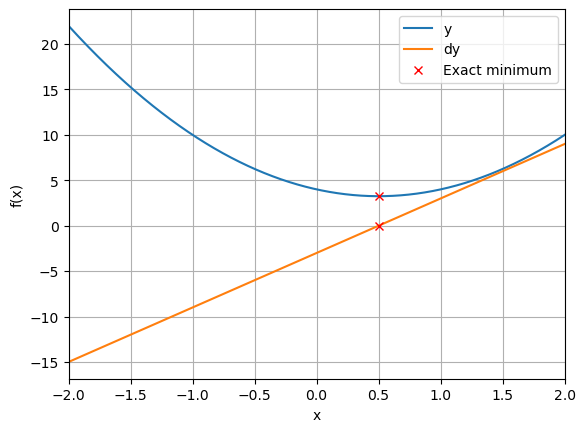

In [113]:
# Example of gradient descent in 1D.
def f(x):
    return 3*x*x - 3*x + 4

def dfdx(x):
    return 6*x - 3

x = np.linspace(-2, 2, 4_001)
plt.plot(x,f(x),x,dfdx(x))
plt.plot([0.5], [f(0.5)], 'rx')
plt.plot([0.5], [dfdx(0.5)], 'rx')
plt.xlim([x[0], x[-1]])
plt.grid()
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend(['y', 'dy', 'Exact minimum'])
plt.show()

In [114]:
learningRate = .01
trainingEpochs = 100

print('Minimum point (x) estimated by GD:')
for attempt in range(10):
    localMinimum = np.random.choice(x, 1)
    for i in range(trainingEpochs):
        gradient = dfdx(localMinimum)
        localMinimum -= gradient * learningRate
    print(f'• {localMinimum[0]}')

Minimum point (x) estimated by GD:
• 0.5012000468659858
• 0.495863537086936
• 0.49671014549239173
• 0.5003945359559406
• 0.5029549099200131
• 0.4987054288945702
• 0.49826979544321914
• 0.4989869467381319
• 0.4994986105559923
• 0.4952799526521074


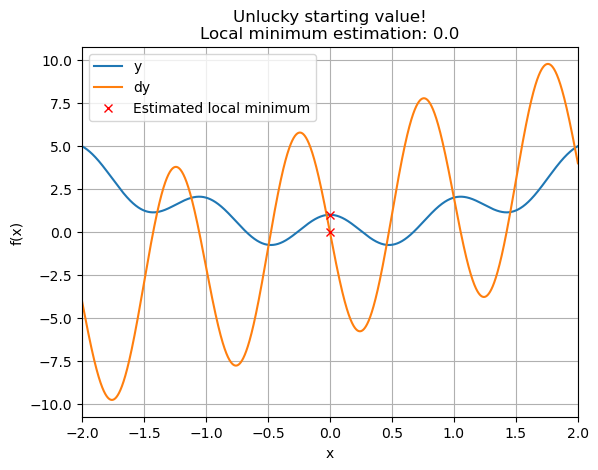

In [115]:
# 1D GD coding challenge
def f(x):
    return np.cos(2 * np.pi * x) + x*x

def dfdx(x):
    return -2 * np.pi * np.sin(2 * np.pi * x) + 2 * x

localMinimum = 0

for i in range(trainingEpochs):
    gradient = dfdx(localMinimum)
    localMinimum -= gradient * learningRate

plt.plot(x,f(x),x,dfdx(x))
plt.xlim([x[0], x[-1]])
plt.plot([localMinimum], [f(localMinimum)], 'rx')
plt.plot([localMinimum], [dfdx(localMinimum)], 'rx')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend(['y', 'dy', 'Estimated local minimum'])
plt.title(f'Unlucky starting value!\nLocal minimum estimation: {localMinimum}')
plt.grid()
plt.show()

In [116]:
# GD in 2D
def fxy(x, y):
    x,y = np.meshgrid(x, y)
    return 3 * (1 - x)**2 * np.exp(-x*x - (y + 1)**2) - 10 * (x/5 - x**3 - y**5) * np.exp(- x*x - y*y) - (1/3) * np.exp(-(x+1)**2 - y**2)

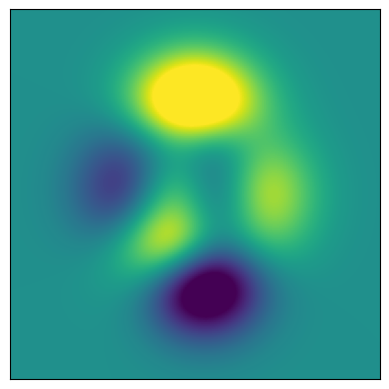

In [117]:
x = np.linspace(-3, 3, 201)
y = np.linspace(-3, 3, 201)

z = fxy(x, y)
plt.imshow(z, extent=[x[0], x[-1], y[0], y[-1]], vmin=-5, vmax=5, origin='lower')
plt.xticks([])
plt.yticks([])
plt.show()

In [118]:
sx, sy = sym.symbols('sx,sy')
sz = 3 * (1 - sx)**2 * sym.exp(-sx*sx - (sy + 1)**2) - 10 * (sx/5 - sx**3 - sy**5) * sym.exp(- sx*sx - sy*sy) - (1/3) * sym.exp(-(sx+1)**2 - sy**2)

dfdx = sym.lambdify((sx, sy), sym.diff(sz, sx), 'sympy') # lambdify turns it into a function
dfdy = sym.lambdify((sx, sy), sym.diff(sz, sy), 'sympy')

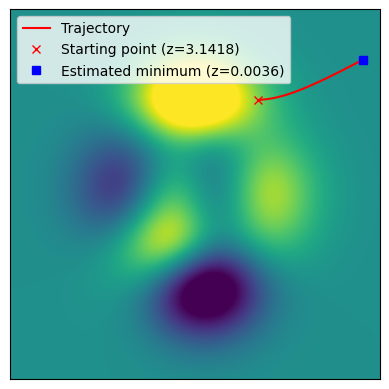

In [119]:
localMinimum = np.array([
    np.random.choice(x),
    np.random.choice(y)
])
startingPoint = localMinimum[:]

learningRate = 0.01
trainingEpochs = 1_000
trajectory = np.zeros((trainingEpochs,2))

for i in range(trainingEpochs):
    grad = np.array([
        dfdx(localMinimum[0], localMinimum[1]).evalf(),
        dfdy(localMinimum[0], localMinimum[1]).evalf()
    ])

    localMinimum = localMinimum - learningRate * grad
    trajectory[i,:] = localMinimum

x = np.linspace(-3, 3, 201)
y = np.linspace(-3, 3, 201)

z = fxy(x, y)
plt.imshow(z, extent=[x[0], x[-1], y[0], y[-1]], vmin=-5, vmax=5, origin='lower')
plt.plot(trajectory[:,0], trajectory[:,1], 'red')
plt.plot(startingPoint[0], startingPoint[1], 'rx')
plt.plot(trajectory[-1,0], trajectory[-1,1], 'bs')

plt.legend(['Trajectory', f'Starting point (z={np.round(fxy(startingPoint[0],startingPoint[1])[0][0],4)})', f'Estimated minimum (z={np.round(fxy(trajectory[-1,0], trajectory[-1,1])[0][0], 4)})'])

plt.xticks([])
plt.yticks([])
plt.show()